# Obesity Prediction – Hyperparameter Tuning & Optimization

## Introduction
This notebook performs comprehensive hyperparameter tuning on the 4 supervised learning models from the previous training phase. Using the baseline results and trained models, we optimize hyperparameters to achieve maximum performance for obesity prediction.

**Models for Tuning:** Random Forest, Logistic Regression, Polynomial Regression (degree 3), XGBoost.

**Tuning Strategy:** GridSearchCV with 5-fold stratified cross-validation for robust hyperparameter optimization.

**Deliverables:**
- Optimized hyperparameters for each model
- Performance comparison between baseline and tuned models
- Best model selection based on comprehensive metrics
- Final evaluation with detailed performance analysis
- Production-ready optimized models saved for deployment

---

## 1. Imports & Configuration

In [13]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import joblib
from datetime import datetime

# Model selection and hyperparameter tuning
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, StratifiedKFold, 
    cross_val_score, train_test_split
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE

# Configure visualization settings
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

print('✅ Imports ready for hyperparameter tuning.')
print(f'⏰ Tuning session started at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✅ Imports ready for hyperparameter tuning.
⏰ Tuning session started at: 2025-09-06 22:05:18


## 2. Load Baseline Results & Data

In [14]:
# Load baseline results from training notebook
results_dir = Path('../results/model_training')
models_dir = Path('../models')

print('📂 LOADING BASELINE RESULTS & DATA')
print('=' * 60)

# Check required files
required_files = {
    'baseline_results': results_dir / 'supervised_learning_results.json',
    'model_comparison': results_dir / 'model_comparison.csv',
    'selected_features': Path('../data/selected_features.csv'),
    'target_classes': Path('../data/target_classes.json'),
    'feature_info': models_dir / 'feature_info.json',
    'scaler': models_dir / 'feature_scaler.pkl'
}

# Check file availability
missing_files = []
for file_type, file_path in required_files.items():
    if not file_path.exists():
        missing_files.append(f'{file_type}: {file_path}')

if missing_files:
    print('❌ Required files missing:')
    for missing in missing_files:
        print(f'   • {missing}')
    print('\n🔧 Please run 04_Model_Training.ipynb first to generate baseline results.')
    raise FileNotFoundError('Missing required files from model training phase.')

# Load baseline results
with open(required_files['baseline_results'], 'r') as f:
    baseline_results = json.load(f)

# Load model comparison (baseline performance)
baseline_df = pd.read_csv(required_files['model_comparison'], index_col='model')

# Load data
df = pd.read_csv(required_files['selected_features'])
with open(required_files['target_classes'], 'r') as f:
    target_classes = json.load(f)
with open(required_files['feature_info'], 'r') as f:
    feature_info = json.load(f)

# Load scaler
scaler = joblib.load(required_files['scaler'])

print('✅ Files loaded successfully!')
print(f'📊 Dataset shape: {df.shape}')
print(f'🏆 Best baseline model: {baseline_results["best_model"]["name"]}')
print(f'📈 Best baseline accuracy: {baseline_results["best_model"]["test_accuracy"]:.4f}')

# Display baseline performance
print('\n📊 Baseline Model Performance:')
display(baseline_df[['Test_Accuracy', 'Test_F1', 'CV_Mean', 'CV_Std']].round(4))

📂 LOADING BASELINE RESULTS & DATA
✅ Files loaded successfully!
📊 Dataset shape: (20758, 26)
🏆 Best baseline model: XGBoost
📈 Best baseline accuracy: 0.9017

📊 Baseline Model Performance:


,Test_Accuracy,Test_F1,CV_Mean,CV_Std
model,,,,
XGBoost,0.9017,0.9012,0.9002,0.0012
Random Forest,0.8967,0.8963,0.8938,0.0036
Polynomial Regression (deg=3),0.8767,0.8761,0.8675,0.0069
Logistic Regression,0.8584,0.8572,0.8558,0.0012


## 3. Data Preparation for Hyperparameter Tuning

In [15]:
# Prepare data (same approach as training notebook)
def prepare_xy(df: pd.DataFrame, target_col='NObeyesdad_encoded'):
    """Prepare features and target from dataframe"""
    if target_col not in df.columns:
        raise KeyError(f'Target column {target_col} not found in dataframe.')
    y = df[target_col].copy()
    X = df.drop(columns=[target_col])
    return X, y

# Prepare features and target
X, y = prepare_xy(df)

# Handle data quality (same as training notebook)
missing_values = X.isnull().sum().sum()
if missing_values > 0:
    X = X.fillna(X.median())

# Convert boolean to numeric
bool_cols = X.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

# Handle non-numeric columns
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if len(non_numeric_cols) > 0:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    for col in non_numeric_cols:
        X[col] = le.fit_transform(X[col])

# Create train/validation/test splits (same as training)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# Apply SMOTE balancing
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train_final)

# Feature scaling
X_train_scaled = scaler.transform(X_train_final)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_train_balanced_scaled = scaler.transform(X_train_balanced)

feature_names = X.columns.tolist()

print('✅ Data preparation complete!')
print(f'📊 Training set: {X_train_final.shape}')
print(f'📊 Validation set: {X_val.shape}')
print(f'📊 Test set: {X_test.shape}')
print(f'📊 Balanced training set: {X_train_balanced.shape}')
print(f'📊 Features: {len(feature_names)}')

✅ Data preparation complete!
📊 Training set: (13284, 25)
📊 Validation set: (3322, 25)
📊 Test set: (4152, 25)
📊 Balanced training set: (18130, 25)
📊 Features: 25


## 3. Hyperparameter Configuration

Define parameter grids for each model to optimize performance through grid search.

In [16]:
# Hyperparameter grids for each model (matching training notebook model names)
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000, 2000]
    },
    
    'Polynomial Regression (deg=3)': {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l2'],
        'classifier__solver': ['lbfgs'],
        'classifier__max_iter': [1000, 2000, 3000]
    },
    
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 6, 10],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }
}

print("Hyperparameter grids defined for all models:")
for model_name, params in param_grids.items():
    print(f"\n{model_name}:")
    for param, values in params.items():
        print(f"  {param}: {values}")

Hyperparameter grids defined for all models:

Random Forest:
  n_estimators: [100, 200, 300]
  max_depth: [10, 15, 20, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']

Logistic Regression:
  C: [0.001, 0.01, 0.1, 1, 10, 100]
  penalty: ['l1', 'l2', 'elasticnet']
  solver: ['liblinear', 'saga']
  max_iter: [1000, 2000]

Polynomial Regression (deg=3):
  classifier__C: [0.001, 0.01, 0.1, 1, 10, 100]
  classifier__penalty: ['l2']
  classifier__solver: ['lbfgs']
  classifier__max_iter: [1000, 2000, 3000]

XGBoost:
  n_estimators: [100, 200, 300]
  max_depth: [3, 6, 10]
  learning_rate: [0.01, 0.1, 0.2]
  subsample: [0.8, 0.9, 1.0]
  colsample_bytree: [0.8, 0.9, 1.0]


## 4. Model Definitions for Tuning

Create model instances with default parameters for hyperparameter optimization.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Define models for hyperparameter tuning (matching training notebook exactly)
models_for_tuning = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    
    'Logistic Regression': LogisticRegression(
        C=1.0,
        penalty='l2',
        solver='lbfgs',
        multi_class='multinomial',
        max_iter=1000,
        random_state=42
    ),
    
    'Polynomial Regression (deg=3)': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            C=0.1,
            penalty='l2',
            solver='lbfgs',
            multi_class='multinomial',
            max_iter=2000,
            random_state=42
        ))
    ]),
    
    'XGBoost': XGBClassifier(
        objective='multi:softprob',
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    )
}

print("Models defined for hyperparameter tuning:")
for name, model in models_for_tuning.items():
    print(f"- {name}: {type(model).__name__}")
    if isinstance(model, Pipeline):
        print(f"  Pipeline steps: {[step[0] for step in model.steps]}")

Models defined for hyperparameter tuning:
- Random Forest: RandomForestClassifier
- Logistic Regression: LogisticRegression
- Polynomial Regression (deg=3): Pipeline
  Pipeline steps: ['poly', 'scaler', 'classifier']
- XGBoost: XGBClassifier


## 5. Hyperparameter Tuning Process

Perform grid search with cross-validation to find optimal hyperparameters for each model.

In [18]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
import time
import warnings
warnings.filterwarnings('ignore')

# Cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scoring metric
scoring = make_scorer(f1_score, average='weighted')

# Store tuned models and results
tuned_models = {}
tuning_results = {}

print("Starting hyperparameter tuning process...")
print("=" * 50)

for model_name in models_for_tuning.keys():
    print(f"\nTuning {model_name}...")
    start_time = time.time()
    
    # Get model and parameter grid
    model = models_for_tuning[model_name]
    param_grid = param_grids[model_name]
    
    # Create GridSearchCV
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=-1,
        verbose=0
    )
    
    # Use appropriate training data based on model type
    if model_name in ['Logistic Regression']:
        fit_X = X_train_balanced_scaled
    elif model_name == 'Polynomial Regression (deg=3)':
        fit_X = X_train_balanced
    else:
        fit_X = X_train_balanced
    
    # Fit the grid search
    grid_search.fit(fit_X, y_train_balanced)
    
    # Store results
    tuned_models[model_name] = grid_search.best_estimator_
    tuning_results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'grid_search': grid_search
    }
    
    end_time = time.time()
    duration = end_time - start_time
    
    print(f"✓ {model_name} completed in {duration:.1f} seconds")
    print(f"  Best CV Score: {grid_search.best_score_:.4f}")
    print(f"  Best Parameters: {grid_search.best_params_}")

print("\n" + "=" * 50)
print("Hyperparameter tuning completed!")

Starting hyperparameter tuning process...

Tuning Random Forest...
✓ Random Forest completed in 632.2 seconds
  Best CV Score: 0.9166
  Best Parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Tuning Logistic Regression...
✓ Logistic Regression completed in 230.0 seconds
  Best CV Score: 0.8482
  Best Parameters: {'C': 1, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}

Tuning Polynomial Regression (deg=3)...
✓ Polynomial Regression (deg=3) completed in 252.1 seconds
  Best CV Score: 0.8656
  Best Parameters: {'classifier__C': 10, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Tuning XGBoost...
✓ XGBoost completed in 1038.8 seconds
  Best CV Score: 0.9212
  Best Parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.8}

Hyperparameter tuning completed!


## 6. Tuned Model Evaluation

Evaluate the performance of tuned models and compare with baseline results.

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Evaluate tuned models (matching training notebook data usage exactly)
tuned_results = {}

print("Evaluating tuned models...")
print("=" * 50)

for model_name, model in tuned_models.items():
    print(f"\n{model_name}:")
    
    # Use the same data selection logic as training notebook
    if model_name in ['Logistic Regression']:
        # Linear models need scaled data
        train_X = X_train_scaled
        val_X = X_val_scaled
        test_X = X_test_scaled
    elif model_name == 'Polynomial Regression (deg=3)':
        # Pipeline handles its own preprocessing
        train_X = X_train_final
        val_X = X_val
        test_X = X_test
    else:
        # Tree-based models use original data
        train_X = X_train_final
        val_X = X_val
        test_X = X_test
    
    # Make predictions
    val_pred = model.predict(val_X)
    test_pred = model.predict(test_X)
    
    # Calculate metrics
   
    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    # Store results
    tuned_results[model_name] = {
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'best_params': tuning_results[model_name]['best_params'],
        'cv_score': tuning_results[model_name]['best_score']
    }
    
  
    print(f"  Validation Accuracy: {val_acc:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  CV Score: {tuning_results[model_name]['best_score']:.4f}")

# Create summary DataFrame
tuned_df = pd.DataFrame.from_dict(tuned_results, orient='index')
print("\n" + "=" * 50)
print("TUNED MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(tuned_df[['val_accuracy', 'test_accuracy', 'cv_score']].round(4))

Evaluating tuned models...

Random Forest:
  Validation Accuracy: 0.8832
  Test Accuracy: 0.8996
  CV Score: 0.9166

Logistic Regression:
  Validation Accuracy: 0.8480
  Test Accuracy: 0.8622
  CV Score: 0.8482

Polynomial Regression (deg=3):
  Validation Accuracy: 0.8597
  Test Accuracy: 0.8786
  CV Score: 0.8656

XGBoost:
  Validation Accuracy: 0.8847
  Test Accuracy: 0.9032
  CV Score: 0.9212

TUNED MODEL PERFORMANCE SUMMARY
                               val_accuracy  test_accuracy  cv_score
Random Forest                        0.8832         0.8996    0.9166
Logistic Regression                  0.8480         0.8622    0.8482
Polynomial Regression (deg=3)        0.8597         0.8786    0.8656
XGBoost                              0.8847         0.9032    0.9212


## 7. Baseline vs Tuned Performance Comparison

Compare the performance improvement achieved through hyperparameter tuning.

BASELINE vs TUNED PERFORMANCE COMPARISON
                           Model  Baseline_Test  Tuned_Test  Improvement  \
0                  Random Forest         0.8967      0.8996       0.0029   
1            Logistic Regression         0.8584      0.8622       0.0039   
2  Polynomial Regression (deg=3)         0.8767      0.8786       0.0019   
3                        XGBoost         0.9017      0.9032       0.0014   

   Improvement_%  
0         0.3223  
1         0.4489  
2         0.2198  
3         0.1603  


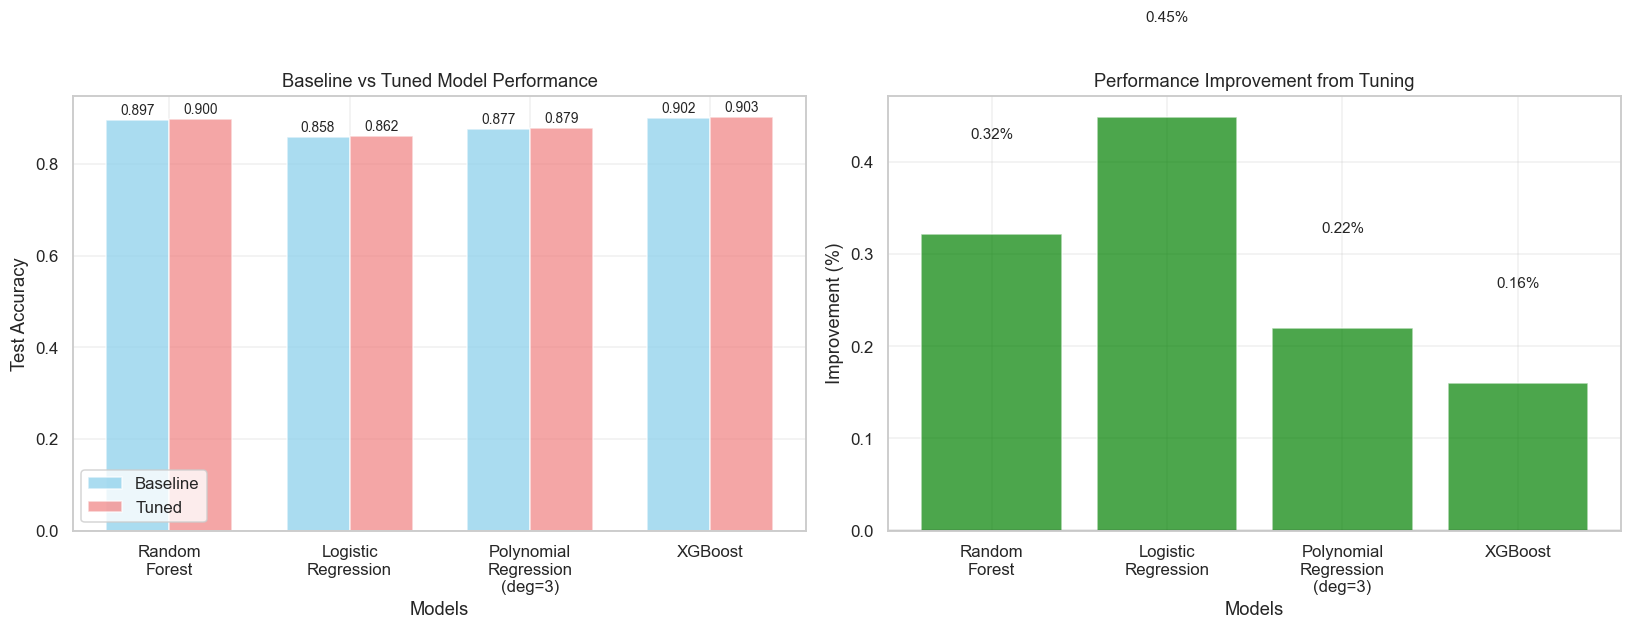


SUMMARY:
Average improvement: 0.29%
Best performing model (tuned): XGBoost
Most improved model: Logistic Regression


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Create comparison DataFrame
comparison_data = []

for model_name in tuned_results.keys():
    if model_name in baseline_df.index:
        baseline_test = baseline_df.loc[model_name, 'Test_Accuracy']
        tuned_test = tuned_results[model_name]['test_accuracy']
        improvement = tuned_test - baseline_test
        
        comparison_data.append({
            'Model': model_name,
            'Baseline_Test': baseline_test,
            'Tuned_Test': tuned_test,
            'Improvement': improvement,
            'Improvement_%': (improvement / baseline_test) * 100
        })

comparison_df = pd.DataFrame(comparison_data)

print("BASELINE vs TUNED PERFORMANCE COMPARISON")
print("=" * 60)
print(comparison_df.round(4))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Performance comparison
x_pos = np.arange(len(comparison_df))
width = 0.35

ax1.bar(x_pos - width/2, comparison_df['Baseline_Test'], width, 
        label='Baseline', alpha=0.7, color='skyblue')
ax1.bar(x_pos + width/2, comparison_df['Tuned_Test'], width, 
        label='Tuned', alpha=0.7, color='lightcoral')

ax1.set_xlabel('Models')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Baseline vs Tuned Model Performance')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([name.replace(' ', '\n') for name in comparison_df['Model']], rotation=0, ha='center')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for i, (baseline, tuned) in enumerate(zip(comparison_df['Baseline_Test'], comparison_df['Tuned_Test'])):
    ax1.text(i - width/2, baseline + 0.005, f'{baseline:.3f}', ha='center', va='bottom', fontsize=9)
    ax1.text(i + width/2, tuned + 0.005, f'{tuned:.3f}', ha='center', va='bottom', fontsize=9)

# Improvement percentage
colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in comparison_df['Improvement_%']]
bars = ax2.bar(comparison_df['Model'], comparison_df['Improvement_%'], color=colors, alpha=0.7)
ax2.set_xlabel('Models')
ax2.set_ylabel('Improvement (%)')
ax2.set_title('Performance Improvement from Tuning')
ax2.set_xticklabels([name.replace(' ', '\n') for name in comparison_df['Model']], rotation=0, ha='center')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# Add value labels on improvement bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + (0.1 if height >= 0 else -0.2),
             f'{height:.2f}%', ha='center', va='bottom' if height >= 0 else 'top', fontsize=10)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nSUMMARY:")
print(f"Average improvement: {comparison_df['Improvement_%'].mean():.2f}%")
print(f"Best performing model (tuned): {comparison_df.loc[comparison_df['Tuned_Test'].idxmax(), 'Model']}")
print(f"Most improved model: {comparison_df.loc[comparison_df['Improvement_%'].idxmax(), 'Model']}")

DETAILED ANALYSIS: XGBoost
Best Parameters:
  colsample_bytree: 0.9
  learning_rate: 0.2
  max_depth: 10
  n_estimators: 300
  subsample: 0.8

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       505
           1       0.87      0.89      0.88       617
           2       0.88      0.89      0.89       582
           3       0.97      0.98      0.97       650
           4       0.99      1.00      1.00       809
           5       0.81      0.76      0.78       485
           6       0.79      0.80      0.79       504

    accuracy                           0.90      4152
   macro avg       0.89      0.89      0.89      4152
weighted avg       0.90      0.90      0.90      4152



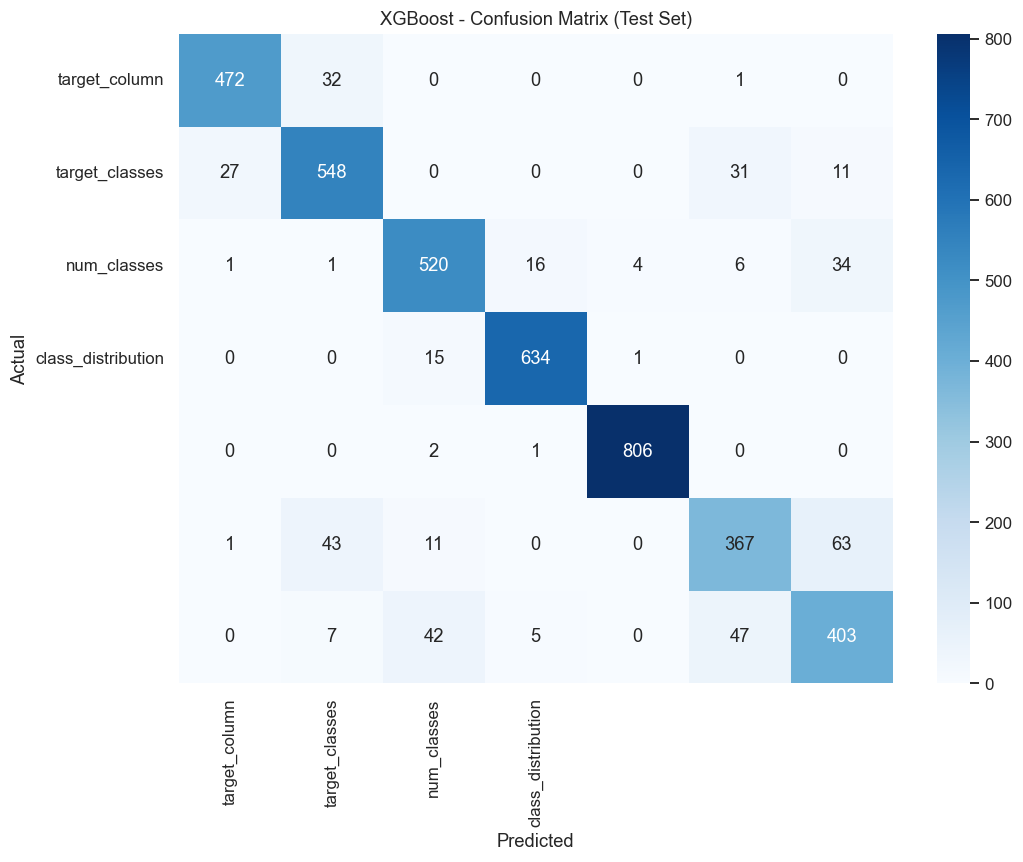


Top 10 Feature Importances:
                           feature  importance
15                          Gender    0.193955
0                              BMI    0.171662
16                   Gender_Female    0.096790
1                           Weight    0.093062
2                    Weight_scaled    0.075934
17                     Gender_Male    0.069218
19                      NCP_scaled    0.023626
24                            CALC    0.021412
20  family_history_with_overweight    0.019942
18                             NCP    0.019285


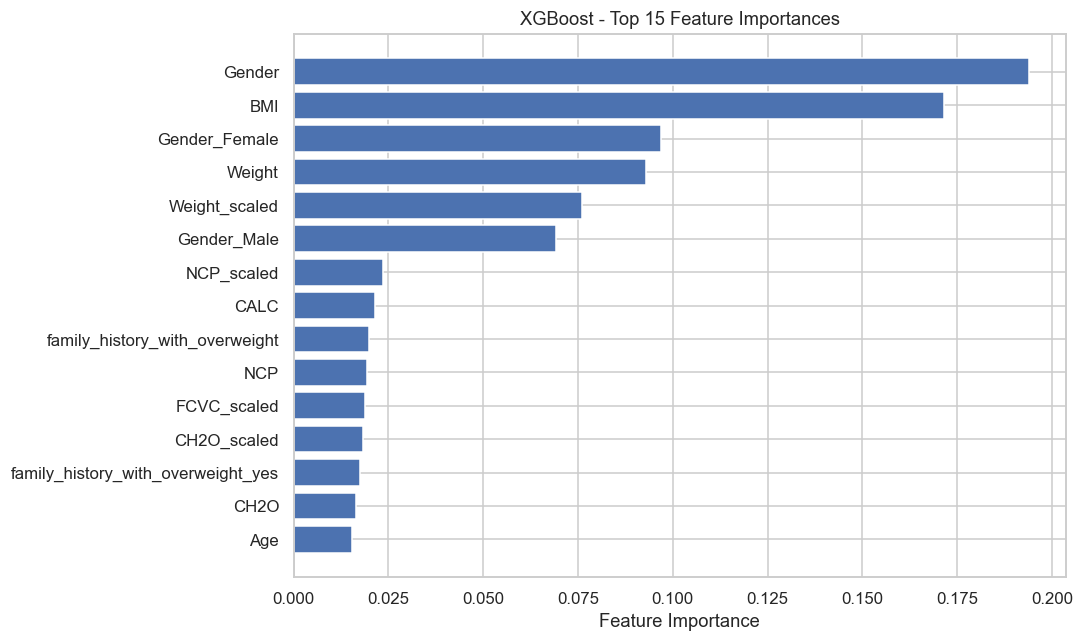

In [25]:
# Find best performing tuned model
best_model_name = comparison_df.loc[comparison_df['Tuned_Test'].idxmax(), 'Model']
best_model = tuned_models[best_model_name]

print(f"DETAILED ANALYSIS: {best_model_name}")
print("=" * 50)

# Best parameters
print(f"Best Parameters:")
for param, value in tuning_results[best_model_name]['best_params'].items():
    print(f"  {param}: {value}")

# Make predictions with best model
y_pred = best_model.predict(X_test)

# Classification report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix visualization
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)

# Create heatmap
import seaborn as sns
plt.subplot(1, 1, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_classes, yticklabels=target_classes)
plt.title(f'{best_model_name} - Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    print(f"\nTop 10 Feature Importances:")
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print(feature_importance_df.head(10))
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    top_features = feature_importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'{best_model_name} - Top 15 Feature Importances')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, 'coef_'):
    print(f"\nModel uses coefficient-based importance (Logistic Regression)")
    # For logistic regression, show coefficient magnitudes
    coef_importance = np.abs(best_model.coef_).mean(axis=0)
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': coef_importance
    }).sort_values('importance', ascending=False)
    
    print(feature_importance_df.head(10))
    
elif isinstance(best_model, Pipeline):
    print(f"\nModel is a Pipeline - checking individual components for feature importance")
    for step_name, step_model in best_model.steps:
        if hasattr(step_model, 'feature_importances_'):
            print(f"Feature importances from {step_name}:")
            print("Available in component model")
        elif hasattr(step_model, 'coef_'):
            print(f"Coefficients available from {step_name}")

## 8. Save Tuned Models and Results

Save the optimized models and performance metrics for future use.

In [28]:
import joblib
import os

# Create models directory if it doesn't exist
tuned_models_dir = models_dir / 'tuned'
tuned_models_dir.mkdir(parents=True, exist_ok=True)

# Save tuned models
print("Saving tuned models...")
model_paths = {}

for model_name, model in tuned_models.items():
    # Clean filename
    safe_name = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('=', '_')
    model_path = tuned_models_dir / f'{safe_name}_tuned.pkl'
    
    # Save model
    joblib.dump(model, model_path)
    model_paths[model_name] = str(model_path)
    print(f"✓ Saved {model_name} to {model_path}")

# Save tuned results
results_path = tuned_models_dir / 'tuned_results.csv'
tuned_df.to_csv(results_path)
print(f"✓ Saved tuned results to {results_path}")

# Save comparison results
comparison_path = tuned_models_dir / 'baseline_vs_tuned_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f"✓ Saved comparison results to {comparison_path}")

# Save hyperparameter details
hyperparams_path = tuned_models_dir / 'best_hyperparameters.txt'
with open(hyperparams_path, 'w') as f:
    f.write("BEST HYPERPARAMETERS FOR EACH MODEL\n")
    f.write("=" * 50 + "\n\n")
    
    for model_name, results in tuning_results.items():
        f.write(f"{model_name}:\n")
        f.write(f"CV Score: {results['best_score']:.4f}\n")
        f.write("Parameters:\n")
        for param, value in results['best_params'].items():
            f.write(f"  {param}: {value}\n")
        f.write("\n")

print(f"✓ Saved hyperparameters to {hyperparams_path}")

# Get best model name from comparison
best_model_name = comparison_df.loc[comparison_df['Tuned_Test'].idxmax(), 'Model']

# Summary
print(f"\nSAVED FILES:")
print(f"- Models directory: {tuned_models_dir}")
print(f"- Number of tuned models: {len(tuned_models)}")
print(f"- Best performing model: {best_model_name}")
print(f"- Best test accuracy: {comparison_df['Tuned_Test'].max():.4f}")

# Create model info dictionary
model_info = {
    'best_model': best_model_name,
    'best_test_accuracy': float(comparison_df['Tuned_Test'].max()),
    'average_improvement': float(comparison_df['Improvement_%'].mean()),
    'model_paths': model_paths,
    'results_path': str(results_path),
    'comparison_path': str(comparison_path),
    'hyperparams_path': str(hyperparams_path)
}

# Save model info
info_path = tuned_models_dir / 'model_info.json'
import json
with open(info_path, 'w') as f:
    json.dump(model_info, f, indent=2)

print(f"✓ Saved model info to {info_path}")

Saving tuned models...
✓ Saved Random Forest to ..\models\tuned\random_forest_tuned.pkl
✓ Saved Logistic Regression to ..\models\tuned\logistic_regression_tuned.pkl
✓ Saved Polynomial Regression (deg=3) to ..\models\tuned\polynomial_regression_deg_3_tuned.pkl
✓ Saved XGBoost to ..\models\tuned\xgboost_tuned.pkl
✓ Saved tuned results to ..\models\tuned\tuned_results.csv
✓ Saved comparison results to ..\models\tuned\baseline_vs_tuned_comparison.csv
✓ Saved hyperparameters to ..\models\tuned\best_hyperparameters.txt

SAVED FILES:
- Models directory: ..\models\tuned
- Number of tuned models: 4
- Best performing model: XGBoost
- Best test accuracy: 0.9032
✓ Saved model info to ..\models\tuned\model_info.json
